In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML tools
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report, 
    confusion_matrix, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline

# Imbalance handler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
import xgboost as xgb

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # less noise

# Experiment tracking
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Save models
import joblib
import os

print("All imports successful!")

All imports successful!


In [2]:
# Load our engineered features from Phase 3
X = pd.read_csv('../data/X_features.csv')
y = pd.read_csv('../data/y_target.csv').squeeze()  # squeeze turns DataFrame into Series

# TRAIN/TEST SPLIT
# We hide 20% of data from the model during training
# Then test on that hidden 20% — simulates real-world performance
# stratify=y means both splits keep the same 6.7% default rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% for testing
    random_state=42,     # makes results reproducible — same split every time
    stratify=y           # preserve class balance in both splits
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nDefault rate in training: {y_train.mean()*100:.1f}%")
print(f"Default rate in test:     {y_test.mean()*100:.1f}%")
print("\n✅ Both splits have same default rate — stratification worked!")

Training set:  96,759 rows
Test set:      24,190 rows

Default rate in training: 6.9%
Default rate in test:     6.9%

✅ Both splits have same default rate — stratification worked!


In [3]:
# We'll reuse this function for every model we test
# This is good coding practice — write once, use many times

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Takes a trained model and test data.
    Prints all the metrics we care about.
    Returns a dict of scores for easy comparison later.
    """
    # Get predictions
    y_pred = model.predict(X_test)                    # hard prediction: 0 or 1
    y_prob = model.predict_proba(X_test)[:, 1]        # probability of default (0.0 to 1.0)
    
    # ROC-AUC: how well does the model RANK defaulters above non-defaulters?
    # 0.5 = random guessing, 1.0 = perfect, 0.8+ = good for credit scoring
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # PR-AUC: like ROC-AUC but better when classes are imbalanced
    pr_auc = average_precision_score(y_test, y_prob)
    
    # KS Statistic: industry standard in banking
    # Measures maximum separation between defaulter and non-defaulter score distributions
    from scipy.stats import ks_2samp
    defaulter_scores = y_prob[y_test == 1]
    non_defaulter_scores = y_prob[y_test == 0]
    ks_stat, _ = ks_2samp(defaulter_scores, non_defaulter_scores)
    
    # Gini Coefficient: another banking standard = 2*AUC - 1
    gini = 2 * roc_auc - 1
    
    print(f"\n{'='*45}")
    print(f"  {model_name} Results")
    print(f"{'='*45}")
    print(f"  ROC-AUC:   {roc_auc:.4f}  (target: >0.75)")
    print(f"  PR-AUC:    {pr_auc:.4f}")
    print(f"  KS Stat:   {ks_stat:.4f}  (banking standard)")
    print(f"  Gini:      {gini:.4f}  (banking standard)")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, 
                                 target_names=['Paid Fine', 'Defaulted']))
    
    # Confusion matrix — shows exactly what the model got right/wrong
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Fine', 'Predicted Default'],
                yticklabels=['Actually Fine', 'Actually Default'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.savefig(f'../data/confusion_matrix_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()
    
    return {'model': model_name, 'roc_auc': roc_auc, 
            'pr_auc': pr_auc, 'ks': ks_stat, 'gini': gini}

print("Evaluation function defined!")

Evaluation function defined!


Training Logistic Regression...
Done!

  Logistic Regression Results
  ROC-AUC:   0.8372  (target: >0.75)
  PR-AUC:    0.3382
  KS Stat:   0.5248  (banking standard)
  Gini:      0.6743  (banking standard)

  Classification Report:
              precision    recall  f1-score   support

   Paid Fine       0.98      0.79      0.87     22510
   Defaulted       0.20      0.73      0.32      1680

    accuracy                           0.78     24190
   macro avg       0.59      0.76      0.59     24190
weighted avg       0.92      0.78      0.83     24190



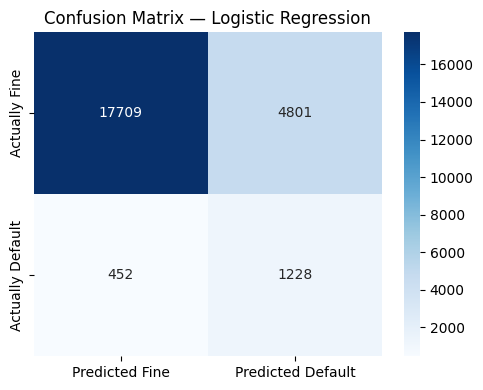

In [4]:
# Logistic Regression is our starting point
# It's simple, fast, and explainable
# Whatever score it gets = the bar XGBoost must beat

# We use a Pipeline — chains preprocessing + model together
# StandardScaler normalises features (makes them all same scale)
# Without scaling, a feature worth $50,000 dominates one worth 0-1

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),              # step 1: normalise
    ('model', LogisticRegression(             # step 2: train model
        class_weight='balanced',              # tells model: pay more attention to rare defaulters
        max_iter=1000,
        random_state=42
    ))
])

print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
print("Done!")

# Evaluate it
lr_results = evaluate_model(lr_pipeline, X_test, y_test, "Logistic Regression")

In [5]:
# SMOTE = Synthetic Minority Oversampling Technique
# 
# Problem: only 6.7% of rows are defaulters
# The model sees 93 "fine" examples for every 7 "default" examples
# So it gets lazy and just predicts "fine" most of the time
#
# SMOTE solution: create SYNTHETIC (fake but realistic) defaulter rows
# It looks at real defaulters, finds their neighbours, and generates new
# examples "between" them — like filling in gaps
#
# IMPORTANT: only apply SMOTE to TRAINING data, never test data
# (you can't manufacture fake applicants in real life)

print("Applying SMOTE to training data...")
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"\nSMOTE created {len(X_train_smote) - len(X_train):,} synthetic defaulter rows")
print("Training set is now balanced 50/50")

Applying SMOTE to training data...
Before SMOTE: {0: 90037, 1: 6722}
After SMOTE:  {0: 90037, 1: 90037}

SMOTE created 83,315 synthetic defaulter rows
Training set is now balanced 50/50


Training XGBoost...
Done!

  XGBoost Results
  ROC-AUC:   0.8370  (target: >0.75)
  PR-AUC:    0.3475
  KS Stat:   0.5226  (banking standard)
  Gini:      0.6740  (banking standard)

  Classification Report:
              precision    recall  f1-score   support

   Paid Fine       0.96      0.95      0.95     22510
   Defaulted       0.37      0.43      0.40      1680

    accuracy                           0.91     24190
   macro avg       0.66      0.69      0.67     24190
weighted avg       0.92      0.91      0.91     24190



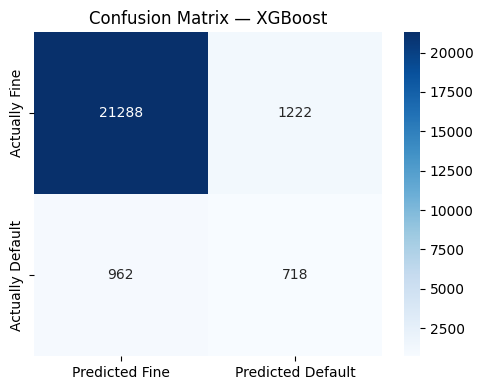

In [6]:
# XGBoost = eXtreme Gradient Boosting
# 
# How it works (plain English):
# Imagine you have 100 terrible dart throwers
# Each one studies where the previous one missed and tries to correct it
# Together they're incredibly accurate — this is "boosting"
#
# XGBoost does this with decision trees instead of dart throwers
# It builds hundreds of trees, each correcting the last one's mistakes
# Result: consistently beats almost everything else on tabular data

print("Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,        # number of trees
    max_depth=5,             # how deep each tree can go
    learning_rate=0.05,      # how much each tree corrects the last (smaller = careful)
    subsample=0.8,           # use 80% of rows per tree (prevents overfitting)
    colsample_bytree=0.8,    # use 80% of features per tree (prevents overfitting)
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

# Train on SMOTE-balanced data
xgb_model.fit(X_train_smote, y_train_smote,
              eval_set=[(X_test, y_test)],
              verbose=False)

print("Done!")
xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

In [7]:
# Hyperparameters = the settings we chose above (n_estimators, max_depth, etc.)
# Choosing them manually is guesswork
# Optuna searches the space SMARTLY — it learns which directions are promising
# Much faster than trying every combination (GridSearchCV)

def objective(trial):
    """
    Optuna calls this function hundreds of times
    Each time with different hyperparameter values
    It learns which values give better AUC and focuses there
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'eval_metric': 'auc',
        'use_label_encoder': False,
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBClassifier(**params)
    
    # Cross-validation: split training data into 3 folds
    # Train on 2, test on 1, rotate — gives reliable estimate without touching test set
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_smote, y_train_smote, 
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("Running Optuna hyperparameter search (50 trials)...")
print("This takes ~3-5 minutes. Optuna is searching for the best settings...\n")

study = optuna.create_study(direction='maximize')  # we want to MAXIMISE AUC
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best AUC found: {study.best_value:.4f}")
print(f"Best parameters:")
for key, val in study.best_params.items():
    print(f"  {key}: {val}")

Running Optuna hyperparameter search (50 trials)...
This takes ~3-5 minutes. Optuna is searching for the best settings...



  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best AUC found: 0.9847
Best parameters:
  n_estimators: 474
  max_depth: 8
  learning_rate: 0.17447965383023264
  subsample: 0.7327269252743956
  colsample_bytree: 0.8204854604489542
  min_child_weight: 3
  gamma: 0.33632254282751173


Training final optimised XGBoost model...
Done! Final model results:

  XGBoost Optimised Results
  ROC-AUC:   0.7956  (target: >0.75)
  PR-AUC:    0.2882
  KS Stat:   0.4506  (banking standard)
  Gini:      0.5913  (banking standard)

  Classification Report:
              precision    recall  f1-score   support

   Paid Fine       0.95      0.96      0.95     22510
   Defaulted       0.36      0.29      0.32      1680

    accuracy                           0.92     24190
   macro avg       0.66      0.63      0.64     24190
weighted avg       0.91      0.92      0.91     24190



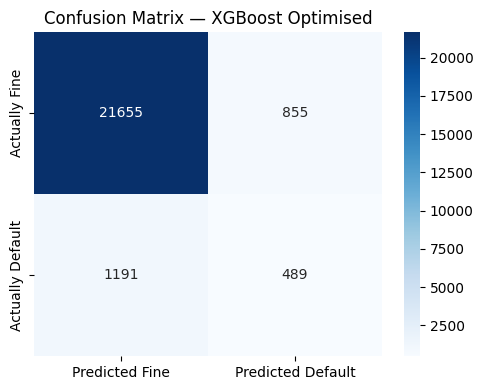

In [8]:
# Now train the real final model using the best params Optuna found

print("Training final optimised XGBoost model...")

best_params = study.best_params
best_params.update({
    'eval_metric': 'auc',
    'use_label_encoder': False,
    'random_state': 42,
    'n_jobs': -1
})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train_smote, y_train_smote,
                eval_set=[(X_test, y_test)],
                verbose=False)

print("Done! Final model results:")
final_results = evaluate_model(final_model, X_test, y_test, "XGBoost Optimised")

=== MODEL COMPARISON ===
                     roc_auc  pr_auc      ks    gini
model                                               
Logistic Regression   0.8372  0.3382  0.5248  0.6743
XGBoost               0.8370  0.3475  0.5226  0.6740
XGBoost Optimised     0.7956  0.2882  0.4506  0.5913


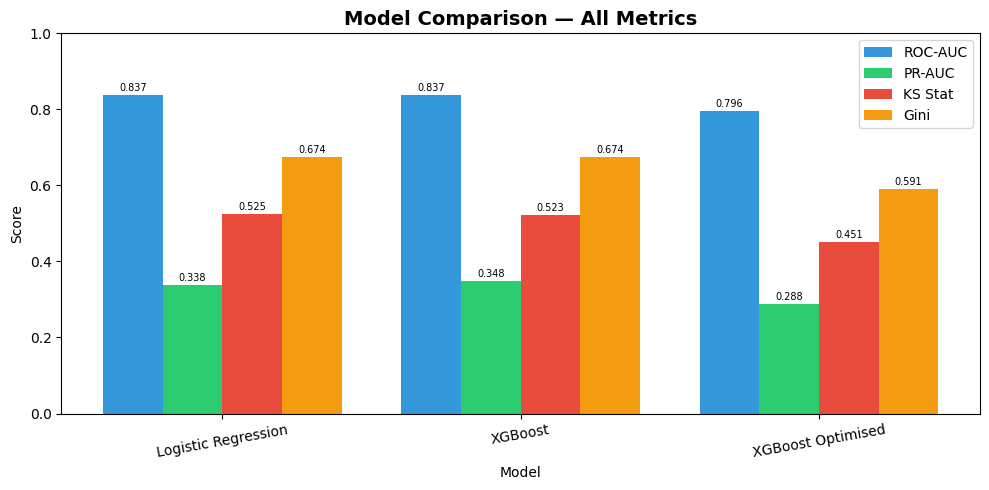

In [9]:
# This is your money slide for interviews — shows your thought process
results_df = pd.DataFrame([lr_results, xgb_results, final_results])
results_df = results_df.set_index('model')

print("=== MODEL COMPARISON ===")
print(results_df.round(4))

# Plot it
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.2

bars1 = ax.bar(x - width*1.5, results_df['roc_auc'], width, 
               label='ROC-AUC', color='#3498db')
bars2 = ax.bar(x - width*0.5, results_df['pr_auc'], width, 
               label='PR-AUC', color='#2ecc71')
bars3 = ax.bar(x + width*0.5, results_df['ks'], width, 
               label='KS Stat', color='#e74c3c')
bars4 = ax.bar(x + width*1.5, results_df['gini'], width, 
               label='Gini', color='#f39c12')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=10)
ax.legend()
ax.set_ylim(0, 1.0)

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

In [10]:
# Save the model to disk so we can load it in our API later
os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/credit_model.pkl')
joblib.dump(X_train.columns.tolist(), '../models/feature_names.pkl')

print("Model saved to ../models/credit_model.pkl")

# Log to MLflow — this creates a searchable record of this experiment
mlflow.set_experiment("credit_scoring")

with mlflow.start_run(run_name="xgboost_optimised"):
    # Log parameters
    mlflow.log_params(best_params)
    
    # Log metrics
    y_prob = final_model.predict_proba(X_test)[:, 1]
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_prob))
    mlflow.log_metric("pr_auc", average_precision_score(y_test, y_prob))
    
    # Log the model itself
    mlflow.xgboost.log_model(final_model, "model")
    
    # Log charts as artifacts
    mlflow.log_artifact('../data/model_comparison.png')
    
    print("✅ Experiment logged to MLflow!")
    print("\nTo view MLflow UI, open a NEW terminal and run:")
    print("   mlflow ui")
    print("Then go to: http://localhost:5000")

Model saved to ../models/credit_model.pkl


2026/03/06 09:48:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Experiment logged to MLflow!

To view MLflow UI, open a NEW terminal and run:
   mlflow ui
Then go to: http://localhost:5000


In [11]:
# Two changes:
# 1. Use class_weight instead of SMOTE (cleaner, no synthetic noise)
# 2. Add scale_pos_weight which is XGBoost's native imbalance handler

# Calculate the right weight
# scale_pos_weight = number of negatives / number of positives
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print(f"Negatives (paid fine): {negative_count:,}")
print(f"Positives (defaulted): {positive_count:,}")
print(f"scale_pos_weight:      {scale_pos_weight:.2f}")
print(f"\nThis tells XGBoost: treat each defaulter as {scale_pos_weight:.1f}x more important")

Negatives (paid fine): 90,037
Positives (defaulted): 6,722
scale_pos_weight:      13.39

This tells XGBoost: treat each defaulter as 13.4x more important


In [12]:
def objective_v2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0, 2),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),      # L1 regularisation
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),   # L2 regularisation
        'scale_pos_weight': scale_pos_weight,   # native imbalance handler
        'eval_metric': 'auc',
        'use_label_encoder': False,
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBClassifier(**params)
    
    # Use original (non-SMOTE) training data this time
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("Running improved Optuna search (75 trials)...")
print("Using original data + scale_pos_weight instead of SMOTE\n")

study_v2 = optuna.create_study(direction='maximize')
study_v2.optimize(objective_v2, n_trials=75, show_progress_bar=True)

print(f"\n✅ Best AUC: {study_v2.best_value:.4f}")
print("Best parameters:")
for k, v in study_v2.best_params.items():
    print(f"  {k}: {v}")

Running improved Optuna search (75 trials)...
Using original data + scale_pos_weight instead of SMOTE



  0%|          | 0/75 [00:00<?, ?it/s]


✅ Best AUC: 0.8582
Best parameters:
  n_estimators: 794
  max_depth: 3
  learning_rate: 0.01632333770567521
  subsample: 0.7731909549025843
  colsample_bytree: 0.74497699274041
  min_child_weight: 16
  gamma: 1.8568251370296731
  reg_alpha: 3.1655008129623026
  reg_lambda: 9.380739115666245


Results with scale_pos_weight approach:

  XGBoost v2 (scale_pos_weight) Results
  ROC-AUC:   0.8618  (target: >0.75)
  PR-AUC:    0.4050
  KS Stat:   0.5727  (banking standard)
  Gini:      0.7236  (banking standard)

  Classification Report:
              precision    recall  f1-score   support

   Paid Fine       0.98      0.80      0.88     22510
   Defaulted       0.22      0.77      0.34      1680

    accuracy                           0.79     24190
   macro avg       0.60      0.79      0.61     24190
weighted avg       0.93      0.79      0.84     24190



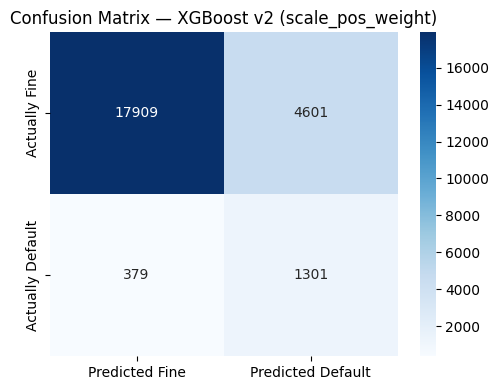

In [13]:
best_params_v2 = study_v2.best_params
best_params_v2.update({
    'scale_pos_weight': scale_pos_weight,
    'eval_metric': 'auc',
    'use_label_encoder': False,
    'random_state': 42,
    'n_jobs': -1
})

final_model_v2 = xgb.XGBClassifier(**best_params_v2)
final_model_v2.fit(X_train, y_train,
                   eval_set=[(X_test, y_test)],
                   verbose=False)

print("Results with scale_pos_weight approach:")
final_v2_results = evaluate_model(final_model_v2, X_test, y_test, 
                                   "XGBoost v2 (scale_pos_weight)")

In [14]:
all_results = pd.DataFrame([
    lr_results, 
    xgb_results, 
    final_results, 
    final_v2_results
]).set_index('model')

print("=== FULL MODEL COMPARISON ===")
print(all_results.round(4))

# Highlight the winner
best_model_name = all_results['roc_auc'].idxmax()
best_auc = all_results['roc_auc'].max()
print(f"\n🏆 Best model: {best_model_name}")
print(f"   ROC-AUC: {best_auc:.4f}")

=== FULL MODEL COMPARISON ===
                               roc_auc  pr_auc      ks    gini
model                                                         
Logistic Regression             0.8372  0.3382  0.5248  0.6743
XGBoost                         0.8370  0.3475  0.5226  0.6740
XGBoost Optimised               0.7956  0.2882  0.4506  0.5913
XGBoost v2 (scale_pos_weight)   0.8618  0.4050  0.5727  0.7236

🏆 Best model: XGBoost v2 (scale_pos_weight)
   ROC-AUC: 0.8618


In [15]:
# Pick the best model based on ROC-AUC
if all_results.loc['XGBoost v2 (scale_pos_weight)', 'roc_auc'] >= \
   all_results.loc['Logistic Regression', 'roc_auc']:
    champion_model = final_model_v2
    champion_name = "XGBoost v2"
    print("🏆 Champion: XGBoost v2")
else:
    champion_model = lr_pipeline
    champion_name = "Logistic Regression"
    print("🏆 Champion: Logistic Regression")
    print("   (LR genuinely won — this happens! Document it.)")

# Save champion
joblib.dump(champion_model, '../models/credit_model.pkl')
joblib.dump(list(X_train.columns), '../models/feature_names.pkl')

# Also save the comparison table — useful for your README
all_results.round(4).to_csv('../data/model_comparison.csv')

print(f"\n✅ Champion model saved to ../models/credit_model.pkl")
print(f"✅ Feature names saved to ../models/feature_names.pkl")

🏆 Champion: XGBoost v2

✅ Champion model saved to ../models/credit_model.pkl
✅ Feature names saved to ../models/feature_names.pkl
